In [2]:
# numpy, pandas 이런 걸로 할 수 있는 기술 통계 기능. 
# 1. 표본추출과 표본자료 생산과정, 
# 2. 생산된 자료의 요약, 수치 및 그래프, 
# 3. 기타 기술 통계 관련 이슈.

# NumPy와 Pandas는 
# 데이터의 수집(표본 추출)부터 요약, 시각화 전처리, 기술 통계적 특성 분석까지 
# 전체 데이터 파이프라인을 효율적으로 처리할 수 있는 
# 파이썬의 핵심 라이브러리입니다.


import numpy as np
import pandas as pd


In [3]:

# ## 1. 표본추출과 표본자료 생산 과정

# 전체 데이터(모집단)에서 목적에 맞는 표본(Sample)을 추출하거나, 통계 실험을 위한 가상 데이터를 생성하는 기능입니다.

# ### 1) 확률적 표본 추출 (Sampling)

# * **단순 무작위 추출 (Simple Random Sampling):**
# **** `np.random.choice()` 또는 `df.sample()`을 활용합니다.
# **** 복원 추출(`replace=True`)과 비복원 추출(`replace=False`)을 모두 지원합니다.

# * **층화 표본 추출 (Stratified Sampling):**
# **** 특정 범주형 변수(예: 성별, 연령대)의 비율을 유지하며 추출할 때 사용합니다.
# **** Pandas의 `groupby()`와 `sample()`을 조합하여 구현합니다.

# # 가상의 모집단 생성
n_pop = 10000              # 모집단 크기 설정. 가성의 모집단 크기임. N  
df_pop = pd.DataFrame({
    'category': np.random.choice(['A', 'B'], size=n_pop, p=[0.7, 0.3]),
    'value': np.random.normal(loc=100, scale=15, size=n_pop)
})
type(df_pop)
# 자료는 (범주, 값). 범주 - A or B 약 7:3의 비율, 값 정규분포(100, 15**2)



pandas.core.frame.DataFrame

### Simple Random Sampling

In [4]:
# 위 가상 모집단 df_pop, 총 관측 1000개 가운데, 일부를 선발, 추출하는 과정.
n_smpld = int(0.125*n_pop)   # 추출 갯수, 비율, 미리 지정해두자. 이래야 나중에 정정 쉽다. 시간도 그렇고, 화면도 그렇고.
n_smpld_frac = 0.125 

# # 1. 단순 무작위 추출 (100개)
simple_sample = df_pop.sample(n_smpld, replace=False, random_state=42)
# simple_sample = df_pop.sample(n=25, replace=False, random_state=42)
# 표본 갯수 n, 비복원추출(이게 디폴트), 검증위한 시드, 42 for fun. 

simple_sample.head()

,category,value
6252,A,107.430183
4684,A,113.349322
1731,A,86.014277
4742,A,103.762241
4521,A,106.380079


### Stratified Random Sampling

In [5]:

# # 2. 층화 표본 추출 (그룹별로 10%씩 비율 유지 추출) 2.5%
# stratified_sample = df_pop.groupby('category', group_keys=False).apply(lambda x: x.sample(frac=n_smpld_frac, random_state=42))
stratified_sample = (
    df_pop
    .groupby('category', group_keys=False)
    .sample(frac=0.025, random_state=42)
    )
# 각 범주(category)의 비중을 그대로 유지하면서 
# 전체 데이터의 2.5%를 일정하게 뽑아내는 층화 추출(Stratified Sampling) 코드
# 줄 바꾸기 연습. 여러 줄로 코딩. 실무적으로 ()로 묶는다. 그리고 점은 다음 줄에 표시하는 게 착오 줄임.
# stratified_sample = (
#     df_pop
#     .groupby('category', group_keys=False)
#     .apply(lambda x: x.sample(frac=n_smpld_frac, random_state=42))
#     )
# groupby() 여기 옵션은 나중 버전에서 달라질 것이라는 코멘트. 이런 코딩을 반대deprecation한다는 코멘트 있네.

stratified_sample.head()
# stratified_sample.tail()
# print(simple_sample, "\n",stratified_sample)
# print("작동 확인, 코드 OK ")
# ```
# ### 2) 표본자료 생산 (난수 생성 및 모의실험)
# * **다양한 확률분포 기반 난수 생성 (`np.random` / `scipy.stats`):**
# * **정규분포:** `np.random.normal(loc=평균, scale=표준편차, size=크기)`
# * **균일분포:** `np.random.uniform(low=최솟값, high=최댓값, size=크기)`
# * **이항분포:** `np.random.binomial(n=시도횟수, p=확률, size=크기)`
# * **포아송분포:** `np.random.poisson(lam=평균발생횟수, size=크기)`
# ---

,category,value
4995,A,103.183243
4266,A,90.215178
7204,A,110.497964
49,A,93.381166
6179,A,106.607771


In [6]:
# 위 데이터 이름 축소. 
dfss1 = simple_sample 
dfss2 = stratified_sample 
# df1의 속성들 알아내기.
# 전체 종합 요약	df.info()	행/열/타입/결측치 한눈에 보기
# 행/열 차원 크기	df.shape	(행 개수, 열 개수) 튜플 반환
# 자료 개수 (행)	len(df) 또는 df.shape[0]	데이터 건수
# 변수 개수 (열)	len(df.columns) 또는 df.shape[1]	컬럼 개수
# 변수 이름 목록	df.columns
dfss1.info()
# df1.shape[0]
# df1.shape[1]
# df1.columns
print("dfss1.shape ")
print(dfss1.shape) 
print("dfss1.columns ")
print(dfss1.columns) 
# ['category', 'value']


<class 'pandas.core.frame.DataFrame'>
Index: 1250 entries, 6252 to 1479
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   category  1250 non-null   object 
 1   value     1250 non-null   float64
dtypes: float64(1), object(1)
memory usage: 29.3+ KB
dfss1.shape 
(1250, 2)
dfss1.columns 
Index(['category', 'value'], dtype='object')


$$ \bar X = { \sum x_i \over n } $$

In [19]:
# ## 2. 생산된 자료의 요약: 수치 및 그래프

# 수집된 데이터의 중심 경향성, 산포도, 분포의 형태를 
# 한눈에 파악하기 위한 요약 기술 통계량 산출 및 시각화 전처리 방법입니다.

# ### 1) 수치적 요약 (Numerical Summaries)
# #### ① 중심 경향성 (Central Tendency)
# * **평균 (Mean):** `df['col'].mean()`, `np.mean(arr)`
# * **중앙값 (Median):** `df['col'].median()`, `np.median(arr)` (이상치 영향에 강함)
# * **최빈값 (Mode):** `df['col'].mode()`
print("평균: ")
print(dfss1['value'].mean())  # 변수 이름을 줘야. 



평균: 
99.86443478562168


\begin{align}
\hat \sigma^2 = { \sum (X_i - \bar X )^2 \over dof }
\end{align}

In [20]:

# #### ② 산포도 (Dispersion)
# * **분산 (Variance) & 표준편차 (Standard Deviation):**
# * Pandas: `df['col'].var()`, `df['col'].std()` $\rightarrow$ 불편추정량(표본분산, $N-1$로 나눔)이 기본값 (`ddof=1`)
# * NumPy: `np.var(arr)`, `np.std(arr)` $\rightarrow$ 모분산($N$으로 나눔)이 기본값 (`ddof=0`) ※ *주의 필요*
print("표준편차: ")
print(dfss1['value'].std(ddof=1))


표준편차: 
14.66890575297428


### 분위수
excel 함수 quartile()과 비슷하면서도 차이가 있음. 

오히려 percentile()에 가까운 함수.

In [21]:

# * **사분위수 범위 (IQR, Interquartile Range):**
# * $Q_3 - Q_1$ 값으로 데이터의 중간 50% 범위를 의미합니다.
# * `Q1 = df['col'].quantile(0.25)`, `Q3 = df['col'].quantile(0.75)`, `IQR = Q3 - Q1`
quant = []
for i in (0.0, 0.25, 0.5, 0.75, 1.0 ) :
    quant.append(dfss1['value'].quantile(i))
print(quant)


[np.float64(44.35661441794473), np.float64(89.68501198785688), np.float64(99.49707549070317), np.float64(109.78313707729974), np.float64(144.48083261565185)]


Range $$ Q_4 - Q_0 $$ 

IQR $$ Q_3 - Q_1 $$

In [22]:

df_quant = dfss1['value'].quantile([0.0, 0.25, 0.5, 0.75, 1.0])  # 이게 훨씬 깔끔. 
print("dfss1 quantile\n", df_quant)  
# type(df_quant)   # 이건 튜블이구나. 아니구나, dataframe이구나...
                        # 행 인덱스로 설정되는 군. 0, 1, 2, 이런 게 아니라, 0.0, 0.25, 이런 값이. 
# print(dfss1['value'].quantile(1.0))
# print(dfss1['value'].quantile(0.75))
# print(dfss1['value'].quantile(0.25))
# print(dfss1['value'].quantile(0.0))

# * **범위 (Range):** `np.ptp(arr)` (Peak-to-Peak) 또는 `df['col'].max() - df['col'].min()`
print("볌위 & IQR :\n", df_quant[1.0]-df_quant[0.0], df_quant[0.75]-df_quant[0.25]) 

# #### ③ 비대칭도 및 첨도 (Shape of Distribution)

# * **왜도 (Skewness):** 분포의 좌우 비대칭도 (`df['col'].skew()`)
# * $0$에 가까우면 대칭, 양수이면 오른쪽 꼬리가 긴 형태(왼쪽으로 쏠림).

# * **첨도 (Kurtosis):** 분포의 뾰족한 정도 및 꼬리의 두께 (`df['col'].kurt()`)



dfss1 quantile
 0.00     44.356614
0.25     89.685012
0.50     99.497075
0.75    109.783137
1.00    144.480833
Name: value, dtype: float64
볌위 & IQR :
 100.12421819770711 20.09812508944286


In [11]:

# #### ④ 일괄 요약 기능
dfss1_summary = dfss1['value'].describe()
skewness = dfss1['value'].skew()
kurtosis = dfss1['value'].kurt()

print("dfss1, simple sample, not ss2 ")
print(dfss1_summary)

# * **Pandas 요약:** `df.describe()`
# * 수치형 변수: 개수(count), 평균(mean), 표준편차(std), 최솟값(min), 사분위수(25%, 50%, 75%), 최댓값(max)을 한 번에 산출.
# * 범주형 변수: `df.describe(include='object')` (개수, 고유값 수, 최빈값, 최빈값 빈도 산출).



dfss1, simple sample, not ss2 
count    1250.000000
mean       99.864435
std        14.668906
min        44.356614
25%        89.685012
50%        99.497075
75%       109.783137
max       144.480833
Name: value, dtype: float64


In [12]:
# ## 깔끔 시도.

# ### 1) 수치적 요약 (Numerical Summaries)
print(" 평 균 :", dfss1['value'].mean())  # 변수 이름을 줘야. 
print("표준편차:", dfss1['value'].std(ddof=1))

dfss1_quant = dfss1['value'].quantile([0.0, 0.25, 0.5, 0.75, 1.0])  # 이게 훨씬 깔끔. 
print("4분위 :\n", df_quant)  
print("볌위:", dfss1_quant[1.0] - dfss1_quant[0.0], "\n",
      "IQR :", dfss1_quant[0.75] - dfss1_quant[0.25]) 

dfss1_skew = dfss1['value'].skew()
dfss1_kurt = dfss1['value'].kurt()
print("skewness: ", dfss1_skew)
print("kurtosis: ", dfss1_kurt)


 평 균 : 99.86443478562168
표준편차: 14.66890575297428
4분위 :
 0.00     44.356614
0.25     89.685012
0.50     99.497075
0.75    109.783137
1.00    144.480833
Name: value, dtype: float64
볌위: 100.12421819770711 
 IQR : 20.09812508944286
skewness:  0.01861760611002714
kurtosis:  0.04402510870450449


In [13]:


# #### ④ 일괄 요약 기능
dfss1_summary = dfss1['value'].describe()
dfss2_summary = dfss2['value'].describe()


print("dfss1, simple sample, not ss2 ")
print(dfss1_summary)

print("dfss2, stratified sample, not ss1 ")
print(dfss2_summary)

# * **Pandas 요약:** `df.describe()`
# * 수치형 변수: 개수(count), 평균(mean), 표준편차(std), 최솟값(min), 사분위수(25%, 50%, 75%), 최댓값(max)을 한 번에 산출.
# * 범주형 변수: `df.describe(include='object')` (개수, 고유값 수, 최빈값, 최빈값 빈도 산출).


dfss1, simple sample, not ss2 
count    1250.000000
mean       99.864435
std        14.668906
min        44.356614
25%        89.685012
50%        99.497075
75%       109.783137
max       144.480833
Name: value, dtype: float64
dfss2, stratified sample, not ss1 
count    250.000000
mean      99.881024
std       14.964048
min       58.658151
25%       89.549454
50%      100.553436
75%      110.002939
max      143.523438
Name: value, dtype: float64


In [14]:

# ```python
# # 기술 통계 일괄 계산 예시
stats_summary = df_pop['value'].describe()
#skewness = df_pop['value'].skew()
#kurtosis = df_pop['value'].kurt()

print("Pop, not sample :")
print(stats_summary)

Pop, not sample :
count    10000.000000
mean        99.795977
std         15.020694
min         37.044487
25%         89.645280
50%         99.987108
75%        109.937118
max        150.257299
Name: value, dtype: float64


## Histogram, density 

<Axes: ylabel='Density'>

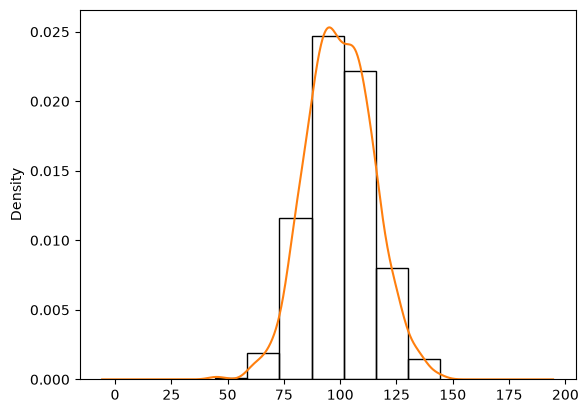

In [15]:

# ### 2) 그래프적 요약 (Graphical Summaries / Visualizations)

# NumPy/Pandas 데이터 구조는 
# `matplotlib` 및 `seaborn` 라이브러리와 완벽하게 연동되며, 
# Pandas 자체 시각화 기능(`df.plot()`)도 제공합니다.

# | 시각화 기법 | 활용 용도 | Pandas / Seaborn 연동 코드 예시 |
# | --- | --- | --- |
# | **히스토그램 (Histogram)** 
#           | 연속형 변수의 빈도 분포 및 왜도 파악     | `df['col'].plot(kind='hist', bins=30)` |
# | **상자 그림 (Box Plot)**   
#           | 사분위수, 중앙값, 이상치(Outlier) 식별  | `df.boxplot(column='col')` |
# | **산점도 (Scatter Plot)**  
#           | 두 연속형 변수 간의 상관관계 및 패턴 파악 | `df.plot(kind='scatter', x='x_col', y='y_col')` |
# | **막대 그래프 (Bar Chart)** 
#           | 범주형 변수의 범주별 빈도/비율 비교   | `df['category'].value_counts().plot(kind='bar')` |
# | **커널 밀도 추정 (KDE)**    
#           | 연속형 변수의 확률 밀도 함수 추정     | `df['col'].plot(kind='kde')` |
dfss1['value'].plot(kind='hist', bins = 7, density=True, facecolor='None', edgecolor='black') 
dfss1['value'].plot(kind='kde') 


<Axes: >

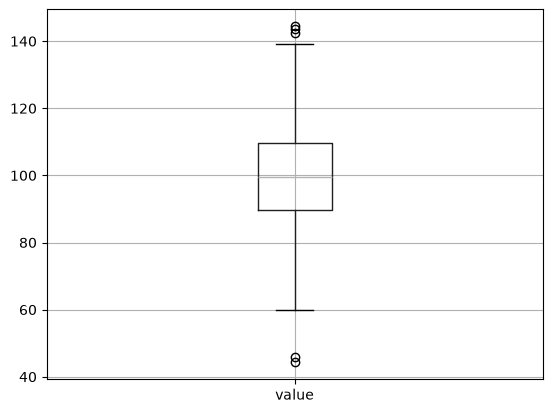

In [16]:
# 상자그림
dfss1.boxplot('value') 



<Axes: xlabel='category'>

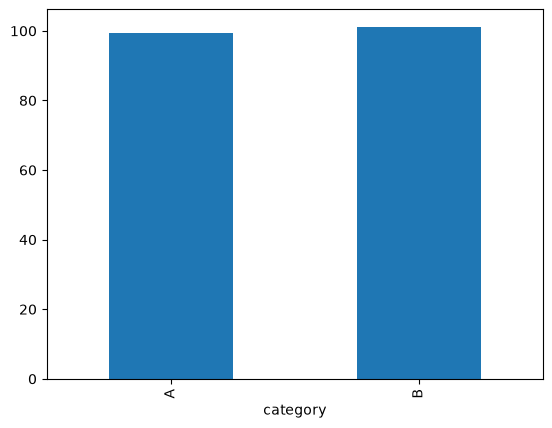

In [17]:
# | **막대 그래프 (Bar Chart)** 
# df_pop['category'].value_counts().plot(kind='bar')    # 이것은 그룹별 갯수.
dfss1.groupby('category')['value'].mean().plot(kind='bar')   # 이것은 그룹별 평균.


In [18]:
# ## 3. 기타 기술 통계 관련 이슈

# 실무 데이터 분석 시 반드시 고려해야 하는 기술 통계적 이슈 및 파이썬 처리 기법입니다.

# ### 1) 결측치 (Missing Values) 처리

# * **기술 통계량 계산 시 영향:**
# **** NumPy(`np.mean`, `np.sum` 등)는 결측치(`NaN`)가 포함되어 있으면 결과가 `NaN`으로 출력됩니다. 
#      (대안: `np.nanmean()`, `np.nansum()` 사용)
# **** Pandas 함수들은 기본적으로 `skipna=True`가 설정되어 있어 `NaN`을 제외하고 통계량을 계산합니다.


# * **대체 기법:** `df['col'].fillna(df['col'].median())` 등을 활용해 평균, 중앙값 또는 앞/뒤 값으로 대체합니다.


# ### 2) 자유도 (Degrees of Freedom, `ddof`) 설정 문제

# * 표본분산/표본표준편차 계산 시 분모를 $N$으로 나눌지, $N-1$로 나눌지에 대한 차이입니다.
# * **Pandas:** 기본 `ddof=1` (표본통계량 계산에 적합)
# * **NumPy:** 기본 `ddof=0` (모통계량 계산에 적합)

# * NumPy에서 표본표준편차를 구할 때는 반드시 `np.std(data, ddof=1)` 옵션을 지정해야 Pandas 결과와 일치합니다.

# ### 3) 이상치 (Outliers) 탐지 및 처리

# * **IQR 기반 탐지법:**
# * 하한선: $Q_1 - 1.5 \times \text{IQR}$
# * 상한선: $Q_3 + 1.5 \times \text{IQR}$
# * 이 범위를 벗어나는 데이터를 이상치로 판정하고 
#      제거(`df.loc[...]`)하거나 윈저라이징(Clipping, `df['col'].clip(...)`) 처리합니다.


# ### 4) 범주형 데이터 및 교차분석 (Crosstab)

# * 두 개 이상의 범주형 변수 간의 관계를 분석할 때 교차표(Contingency Table)를 생성합니다.
# * `pd.crosstab(df['cat1'], df['cat2'], margins=True, normalize='all')` 
#    구문을 통해 빈도수 및 비율을 한눈에 집계할 수 있습니다.

# ### 5) 상관관계 분석 (Correlation)

# * 연속형 변수 간의 선형적 관련성을 파악하기 위해 상관계수를 계산합니다.
# * `df.corr(method='pearson')` (비선형/순위 데이터의 경우 `method='spearman'` 활용).